Inverse Sampling; Box-Muller unwahrscheinlich, dass die Formel dran kommt; Wie kann man bei inverse multivariate werden mit covariance; Rejection sampling wichtig

# Sampling Methods

Many tasks in machine learning require **drawing random samples** from a probability distribution — to approximate an expectation, to simulate a model, or to generate new data. But a computer can only produce (pseudo-)random numbers from a *uniform* distribution on $[0, 1]$. So how do we turn those uniform numbers into samples from *any* distribution we want?

This notebook builds several classic answers to that question, all from scratch:

1. **Inverse transform sampling** — reshaping uniform samples with a distribution's inverse CDF (exponential, cosine, logistic).
2. **The Box–Muller transform** — a geometric trick for generating Gaussian samples, extended to the bivariate case.
3. **Ancestral sampling** — sampling from a mixture of Gaussians by first picking a component, then sampling from it.
4. **Rejection sampling** — sampling from a complicated density using a simple *proposal* distribution and discarding samples that don't fit.

Throughout, we check each sampler by plotting a **histogram of the generated samples** against the **true density**: if the sampler is correct, the histogram should trace the density curve.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rcParams

rcParams['figure.figsize'] = (4, 3)
plt.style.use('ggplot')

## Inverse Transform Sampling

The simplest way to convert uniform samples into samples from a target distribution uses the **cumulative distribution function (CDF)**
$$F(x) = P(X \le x) = \int_{-\infty}^{x} p(t)\,dt.$$

The CDF is monotonically increasing and maps any value $x$ to a number in $[0, 1]$. The **inversion method** runs this map *backwards*:

1. Draw a uniform sample $u \sim \mathcal{U}(0, 1)$.
2. Return $x = F^{-1}(u)$, where $F^{-1}$ is the **inverse CDF** (also called the *quantile function*).

**Why does this work?** A uniform sample $u$ is equally likely to land anywhere in $[0,1]$. The inverse CDF stretches the regions of $[0,1]$ where the density is high over a wide range of $x$, and squeezes the low-density regions — so the resulting $x$ values follow exactly $p(x)$.

To use the method we need three ingredients per distribution: the **pdf** $p(x)$ (to check our result), the **cdf** $F(x)$, and the **inverse cdf** $F^{-1}(u)$.

### Exponential distribution

The exponential distribution has density
$$p(x \mid \lambda)=\begin{cases} \lambda e^{-\lambda x} & x \geq 0 \\ 0 & x<0 \end{cases}$$

Integrating the pdf gives the CDF $F(x) = 1 - e^{-\lambda x}$, which we can invert by hand: setting $u = 1 - e^{-\lambda x}$ and solving for $x$ yields
$$F^{-1}(u) = -\frac{\ln(1 - u)}{\lambda}.$$

> **Complete the class below** by implementing `pdf`, `cdf`, `inverse_cdf`, and `sample`. The `sample` method should draw uniform samples and push them through `inverse_cdf`.

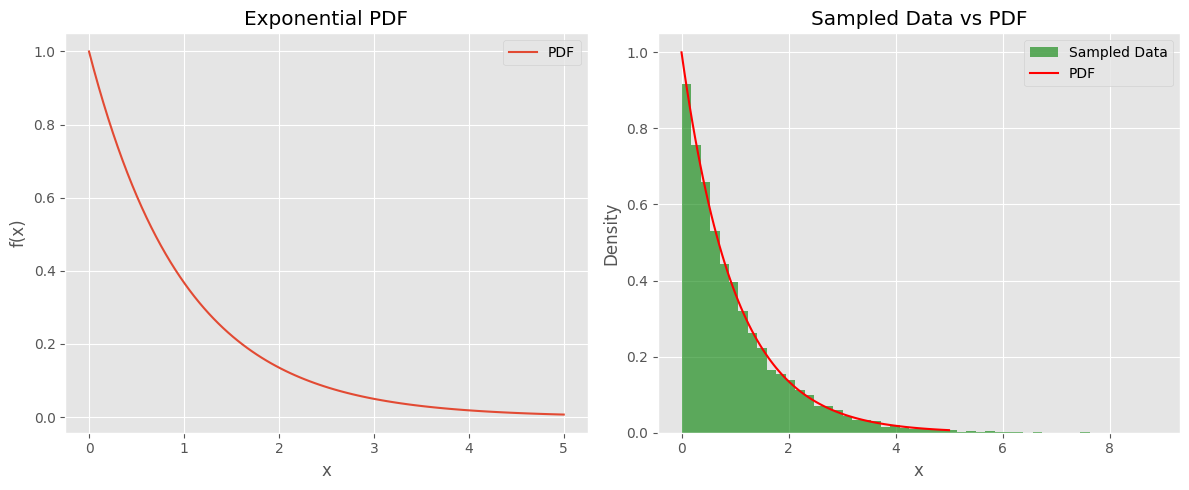

In [2]:
class ExponentialDistribution:
    def __init__(self, lmb):
        self.lmb = lmb

####################
# Your Code Here   #
####################
        self.inv_cdf = lambda u: -np.log(1 - u) / self.lmb

    def sample(self, n_samples):
####################
# Your Code Here   #
####################
        uniform_samples = np.random.uniform(0, 1, n_samples)
        return np.array([self.inv_cdf(u) for u in uniform_samples])


n_samples = 10000
dist = ExponentialDistribution(lmb=1)
y = dist.sample(n_samples)

# Plot the uniform-to-CDF mapping (left) and the transformed samples vs. the pdf (right).
####################
# Your Code Here   #
####################
x = np.linspace(0, 5, 100)
pdf = dist.lmb * np.exp(-dist.lmb * x)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf, label='PDF')
plt.title('Exponential PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(y, bins=50, density=True, alpha=0.6, color='g', label='Sampled Data')
plt.plot(x, pdf, label='PDF', color='r')
plt.title('Sampled Data vs PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Cosine distribution

Next, a density supported only on $[0, \pi/2]$:
$$p(x) = \begin{cases} \cos(x) & x \in [0, \pi/2] \\ 0 & \text{otherwise} \end{cases}$$

Its CDF on the support is $F(x) = \sin(x)$, so the inverse CDF is $F^{-1}(u) = \arcsin(u)$. Here $u \in [0,1]$ maps into $[0, \pi/2]$ — exactly the support of the distribution.

> **Fill in** `pdf`, `cdf`, `inverse_cdf`, and `sample` for the cosine distribution.

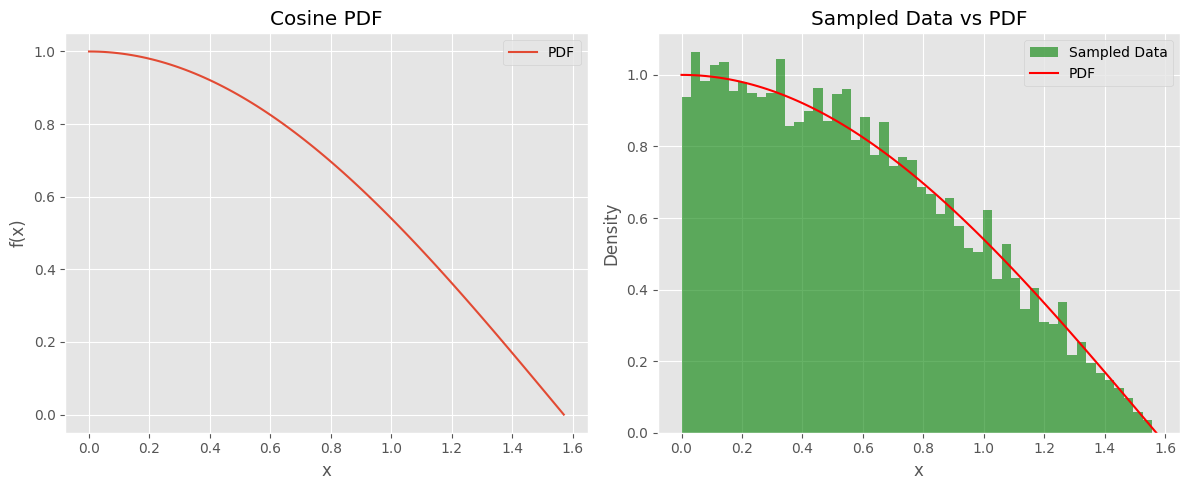

In [3]:
class CosineDistribution:
####################
# Your Code Here   #
####################
    def __init__(self):
        self.pdf = lambda x: np.cos(x) if 0 <= x <= np.pi / 2 else 0
        self.cdf = lambda x: np.sin(x) if 0 <= x <= np.pi / 2 else (1 if x > np.pi / 2 else 0)
        self.inv_cdf = lambda u: np.arcsin(u)

    def sample(self, n_samples):
####################
# Your Code Here   #
####################
        uniform_samples = np.random.uniform(0, 1, n_samples)
        return np.array([self.inv_cdf(u) for u in uniform_samples])


n_samples = 10000
dist = CosineDistribution()
y = dist.sample(n_samples)

####################
# Your Code Here   #
####################
x = np.linspace(0, np.pi / 2, 100)
pdf = np.cos(x)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf, label='PDF')
plt.title('Cosine PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(y, bins=50, density=True, alpha=0.6, color='g', label='Sampled Data')
plt.plot(x, pdf, label='PDF', color='r')
plt.title('Sampled Data vs PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Logistic distribution

Finally, the logistic distribution, whose pdf and CDF are
$$p(x) = \frac{e^{-x}}{\left(1+e^{-x}\right)^{2}} \qquad F(x) = \frac{1}{1+e^{-x}}.$$

The CDF is the familiar **sigmoid** function. Inverting it gives the *logit* $F^{-1}(u) = \ln\!\frac{u}{1-u}$ (equivalently $-\ln(1/u - 1)$).

> **Implement** the logistic distribution.

**Python note — `np.clip`:** the inverse CDF blows up as $u \to 0$ or $u \to 1$. We `np.clip` the uniform samples to $[10^{-10},\, 1 - 10^{-10}]$ to keep the logarithm finite — a small numerical safeguard.

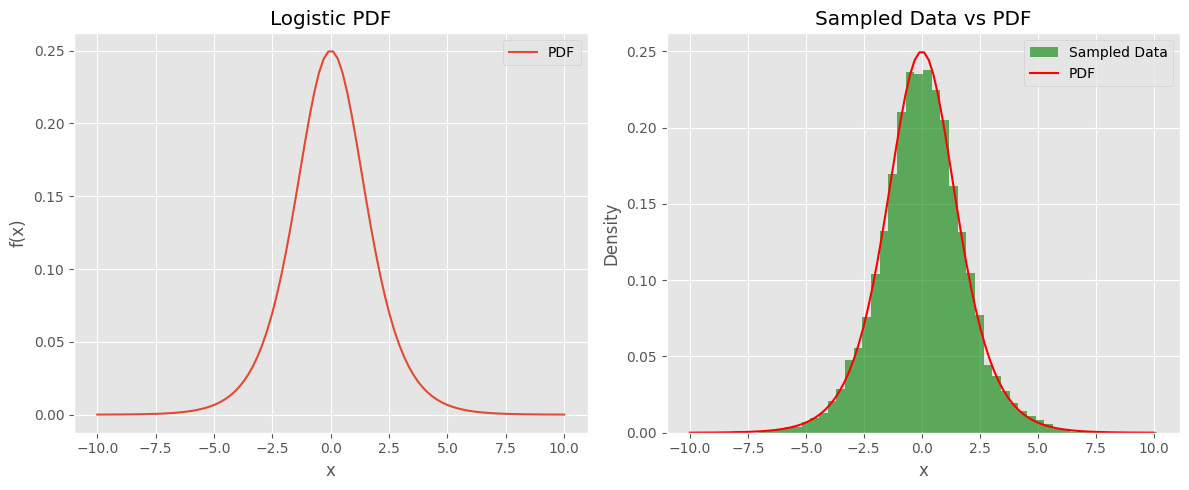

In [4]:
class LogisticDistribution:
####################
# Your Code Here   #
####################
    def __init__(self):
        self.pdf = lambda x: np.exp(-x) / ((1 + np.exp(-x)) ** 2)
        self.cdf = lambda x: 1 / (1 + np.exp(-x))
        self.inv_cdf = lambda u: -np.log(1 / u - 1)

    def sample(self, n_samples):
####################
# Your Code Here   #
####################
        uniform_samples = np.random.uniform(0, 1, n_samples)
        return np.array([self.inv_cdf(u) for u in uniform_samples])


n_samples = 10000
dist = LogisticDistribution()
y = dist.sample(n_samples)

####################
# Your Code Here   #
####################
x = np.linspace(-10, 10, 100)
pdf = np.exp(-x) / ((1 + np.exp(-x)) ** 2)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(x, pdf, label='PDF')
plt.title('Logistic PDF')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(y, bins=50, density=True, alpha=0.6, color='g', label='Sampled Data')
plt.plot(x, pdf, label='PDF', color='r')
plt.title('Sampled Data vs PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## The Box–Muller Transform

Inverse transform sampling needs a tractable inverse CDF — but the Gaussian's CDF has no closed-form inverse, so we need a different idea. The **Box–Muller transform** generates Gaussian samples using a geometric trick.

The *polar* form used here works like this:
1. Sample a point $(z_1, z_2)$ uniformly from the square $[-1, 1]^2$ and **reject** it if it falls outside the unit circle, so the accepted points are uniform on the disk.
2. With $r^2 = z_1^2 + z_2^2$, the following transform turns the two coordinates into two **independent standard normal** samples:
$$y_i = z_i \sqrt{\frac{-2 \ln r^2}{r^2}}$$
3. To obtain a Gaussian with a desired mean $\boldsymbol{\mu}$ and covariance $\boldsymbol{\Sigma}$, we shift and stretch the standard-normal samples using the **Cholesky factor** $L$ (where $\boldsymbol{\Sigma} = LL^\top$): $\;\boldsymbol{y} \mapsto \boldsymbol{\mu} + \boldsymbol{y}\,L^\top$.

> **Implement the Box–Muller algorithm** to draw samples from a bivariate normal, and compare them against `np.random.multivariate_normal` with a scatter plot.

**Python note — Cholesky:** `np.linalg.cholesky(cov)` returns the matrix $L$. Multiplying standard-normal samples by $L^\top$ gives them the desired covariance.

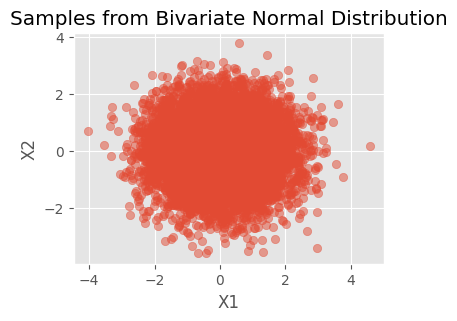

In [21]:
####################
# Your Code Here   #
####################
def box_muller(n_samples, mean=np.zeros(2), cov=np.eye(2)):
    z1 = np.array([])
    z2 = np.array([])
    while len(z1) < n_samples and len(z2) < n_samples:
        z1 = np.append(z1, np.random.uniform(-1, 1, n_samples - len(z1)))
        z2 = np.append(z2, np.random.uniform(-1, 1, n_samples - len(z2)))
        # mask to filter out points outside the unit circle
        mask = z1 ** 2 + z2 ** 2 < 1
        z1 = z1[mask]
        z2 = z2[mask]
    r2 = z1 ** 2 + z2 ** 2
    y1 = z1 * np.sqrt(-2 * np.log(r2) / r2)
    y2 = z2 * np.sqrt(-2 * np.log(r2) / r2)
    samples = np.column_stack((y1, y2))
    return mean + samples @ np.linalg.cholesky(cov).T

samples = box_muller(10000)
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.title('Samples from Bivariate Normal Distribution')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Ancestral Sampling from a Mixture of Gaussians

A **mixture of Gaussians** generates a point in two stages: first pick a component $k$ with probability $\pi_k$, then draw a point from that component's Gaussian $\mathcal{N}(\boldsymbol{\mu}_k, \boldsymbol{\Sigma}_k)$. Sampling by following this generative story step by step — parents (the component choice) before children (the point) — is called **ancestral sampling**.

The recipe:
1. Draw the component label for each of the $n$ samples from the categorical distribution given by the mixing coefficients (`np.random.choice` with `p=coefs`).
2. For each component, use the Box–Muller sampler from above to draw the points assigned to it.

> **Extend the code above** to sample from a mixture of Gaussians, reusing your `BoxMuller` class for each component.

**What to look for:** the scatter plot should show three blobs of different sizes, shapes, and densities — matching the three components and their mixing weights $[0.1, 0.4, 0.5]$.

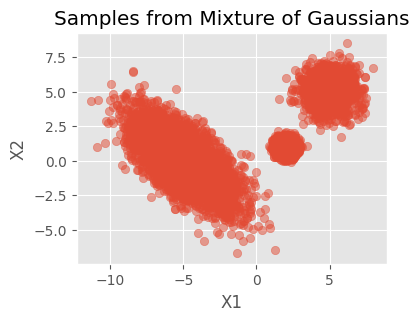

In [22]:
coefs = [0.1, 0.4, 0.5]
means = [[5, 5], [-5, 0], [2, 1]]
covs = [
    [[1, 0], [0, 1]],
    [[3, -2], [-2, 3]],
    [[.1, 0], [0, .1]],
]

####################
# Your Code Here   #
####################

def ancestral_sampling(n_samples):
    samples = []
    for _ in range(n_samples):
        # Pick a component based on its weight
        component = np.random.choice(len(coefs), p=coefs)
        # Sample from the selected component
        sample = box_muller(1, mean=means[component], cov=covs[component])[0]
        samples.append(sample)
    return np.array(samples)

samples = ancestral_sampling(10000)
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.title('Samples from Mixture of Gaussians')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Rejection Sampling

Sometimes we can *evaluate* a density $\tilde p(z)$ (possibly unnormalized) but have no way to invert its CDF or transform it directly. **Rejection sampling** handles this with a simpler **proposal distribution** $q(z)$ that we *can* sample from.

We pick a constant $k$ large enough that $k\,q(z) \ge \tilde p(z)$ everywhere — the scaled proposal forms an *envelope* over the target. Then we repeat:
1. Draw a candidate $z_0 \sim q(z)$.
2. Draw $u_0 \sim \mathcal{U}\big(0,\, k\,q(z_0)\big)$ — a random height under the envelope at $z_0$.
3. **Accept** $z_0$ if $u_0 \le \tilde p(z_0)$, otherwise **reject** it.

The accepted samples follow $p(z)$. Geometrically, we throw points uniformly under the envelope and keep only those that also fall under $\tilde p$ — the gray gap in the plot below is the rejected region.

The plot shows the (unnormalized) target $\tilde p(z)$, the envelope $k\,q(z)$, and the rejected region between them.

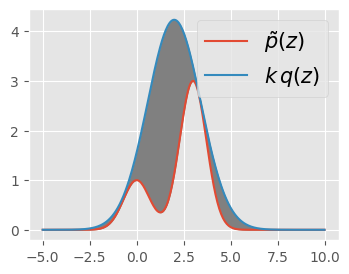

In [15]:
from scipy.stats import norm as gauss
np.random.seed(42)

k = 15
# We can sample from the proposal q with q_dist.rvs(...).
q_dist = gauss(loc=np.array([2.]), scale=np.sqrt([2]))
def p_dist(x):
    return np.exp(-x ** 2) + 3 * np.exp(-(x - 3) ** 2)


axis = np.linspace(-5, 10, 301)
plt.plot(axis, p_dist(axis), label=r"$\tilde{p}(z)$")
plt.plot(axis, k * q_dist.pdf(axis), label=r"$k\,q(z)$")
plt.fill_between(axis, p_dist(axis), k * q_dist.pdf(axis), color="gray")
plt.legend(fontsize=15)
plt.show()

> **Implement rejection sampling** in the class below: in a loop, propose candidates from `q_dist`, draw the uniform heights, keep the candidates that fall under `p_dist`, and repeat until `n_samples` points have been accepted.

**What to look for:** the histogram of accepted samples should match the shape of $\tilde p(z)$ — two bumps, the right one about three times taller than the left.

In [16]:
####################
# Your Code Here   #
####################
def rejection_sampling(n_samples):
    samples = []
    while len(samples) < n_samples:
        z = q_dist.rvs()
        u = np.random.uniform(0, k * q_dist.pdf(z))
        if u < p_dist(z):
            samples.append(z)
    return np.array(samples)

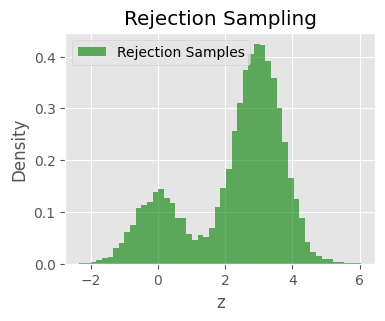

In [18]:
####################
# Your Code Here   #
####################
samples = rejection_sampling(10000)
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g', label='Rejection Samples')
plt.title('Rejection Sampling')
plt.xlabel('z')
plt.ylabel('Density')
plt.legend()
plt.show()

#### Discussion questions

1. How does the choice of the proposal $q$ (and the constant $k$) affect the efficiency of rejection sampling?
####################
 Your Text Here   
####################

2. Why does rejection sampling become impractical in high dimensions?
####################
 Your Text Here   
####################